In [1]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt

In [3]:
# Loading and timestamp conversion
df = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv"
)
df['ts'] = pd.to_datetime(
    df['ts'],
    format='mixed',
    utc=True
)
df = df.sort_values(
    ['host_id', 'ts']
)
df.head()

,id,ts,host_id,cpu_usage_pct,memory_usage_pct,power_kw,status,hostName,inlet_temp_c,cpu_temp_c,...,thermal_gradient,temp_rate_of_change,temp_roll_mean_12,cpu_per_kw,temp_per_cpu,resource_stress_index,timestamp_display,hour_of_day,day_of_week,is_weekend
49502,34,2026-04-02 12:44:09.710000+00:00,1,4.0,74.0,0.221,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.099548,7.600000,39.0,02-04-2026 12:44,12,3,0
49503,37,2026-04-02 12:46:02.041000+00:00,1,4.0,74.0,0.220,Normal,10.10.10.65,21,38,...,17,0.0,38.0,18.181818,7.600000,39.0,02-04-2026 12:46,12,3,0
49504,40,2026-04-02 12:47:28.840000+00:00,1,4.0,74.0,0.220,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.181818,7.600000,39.0,02-04-2026 12:47,12,3,0
49505,43,2026-04-02 12:49:08.515000+00:00,1,6.0,74.0,0.221,Normal,10.10.10.65,21,38,...,17,0.0,38.0,27.149321,5.428571,40.0,02-04-2026 12:49,12,3,0
49506,46,2026-04-02 12:51:17.199000+00:00,1,4.0,74.0,0.222,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.018018,7.600000,39.0,02-04-2026 12:51,12,3,0


In [4]:
# Select one server
SERVER_ID = 2
df = df[
    df['host_id'] == SERVER_ID
].copy()

print(df.shape)

(24751, 31)


In [5]:
# Create 12 historical CPU Lags
for lag in range(1, 13):
    
    df[f'cpu_lag_{lag}'] = (
        df['cpu_usage_pct']
        .shift(lag)
    )

# Remove missing rows
df = df.dropna()
print(df.shape)

(24739, 41)


In [6]:
# Features
FEATURES = [
    'cpu_lag_1',
    'cpu_lag_2',
    'cpu_lag_3',
    'cpu_lag_4',
    'cpu_lag_5',
    'cpu_lag_6',
    'cpu_lag_7',
    'cpu_lag_8',
    'cpu_lag_9',
    'cpu_lag_10',
    'cpu_lag_11',
    'cpu_lag_12',
    'memory_usage_pct',
    'power_kw',
    'cpu_temp_c',
    'inlet_temp_c',
    'cpu_change',
    'cpu_roll_mean_3',
    'cpu_volatility',

    'resource_stress_index',

    'hour_of_day',
    'day_of_week',
    'is_weekend'
]

TARGET = 'cpu_usage_pct'

In [7]:
# Train-test split
split_index = int(
    len(df) * 0.8
)

train_df = df.iloc[:split_index]

test_df = df.iloc[split_index:]

print(train_df.shape)
print(test_df.shape)

# create X and y
X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

(19791, 41)
(4948, 41)


In [8]:
# Train XGBoost
model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(
    X_train,
    y_train
)

# Predict
predictions = model.predict(
    X_test
)

In [9]:
# Metrics
mae = mean_absolute_error(
    y_test,
    predictions
)
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)
r2 = r2_score(
    y_test,
    predictions
)
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.18319453088622376
RMSE: 0.2833102663773294
R²  : 0.9113112046635945


In [10]:
# Results dataframe
results = pd.DataFrame({

    'Timestamp': test_df['ts'],
    'Actual': y_test,
    'Predicted': predictions
})
results.head(10)

,Timestamp,Actual,Predicted
19803,2026-05-25 00:19:20.486000+00:00,1.0,0.997670
19804,2026-05-25 00:24:18.700000+00:00,2.0,2.000312
19805,2026-05-25 00:29:17.056000+00:00,4.0,3.925012
19806,2026-05-25 00:34:19.451000+00:00,3.0,2.942266
19807,2026-05-25 00:39:16.931000+00:00,4.0,4.008318
19808,2026-05-25 00:44:17.214000+00:00,3.0,2.992435
19809,2026-05-25 00:49:19.631000+00:00,3.0,2.977381
19810,2026-05-25 00:54:18.602000+00:00,3.0,2.976449
19811,2026-05-25 00:59:16.743000+00:00,3.0,2.974931
19812,2026-05-25 01:04:18.608000+00:00,3.0,2.975296


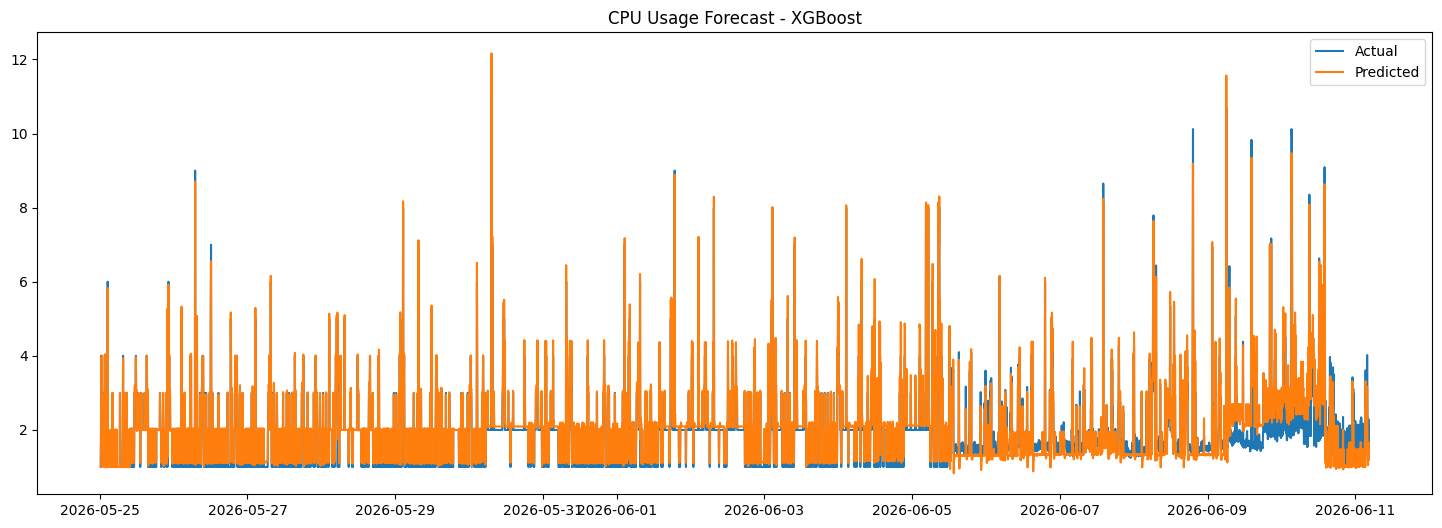

In [11]:
# Actual vs Predicted plot
plt.figure(
    figsize=(18,6)
)
plt.plot(
    results['Timestamp'],
    results['Actual'],
    label='Actual'
)
plt.plot(
    results['Timestamp'],
    results['Predicted'],
    label='Predicted'
)
plt.legend()
plt.title(
    "CPU Usage Forecast - XGBoost"
)

plt.show()

10.10.10.150


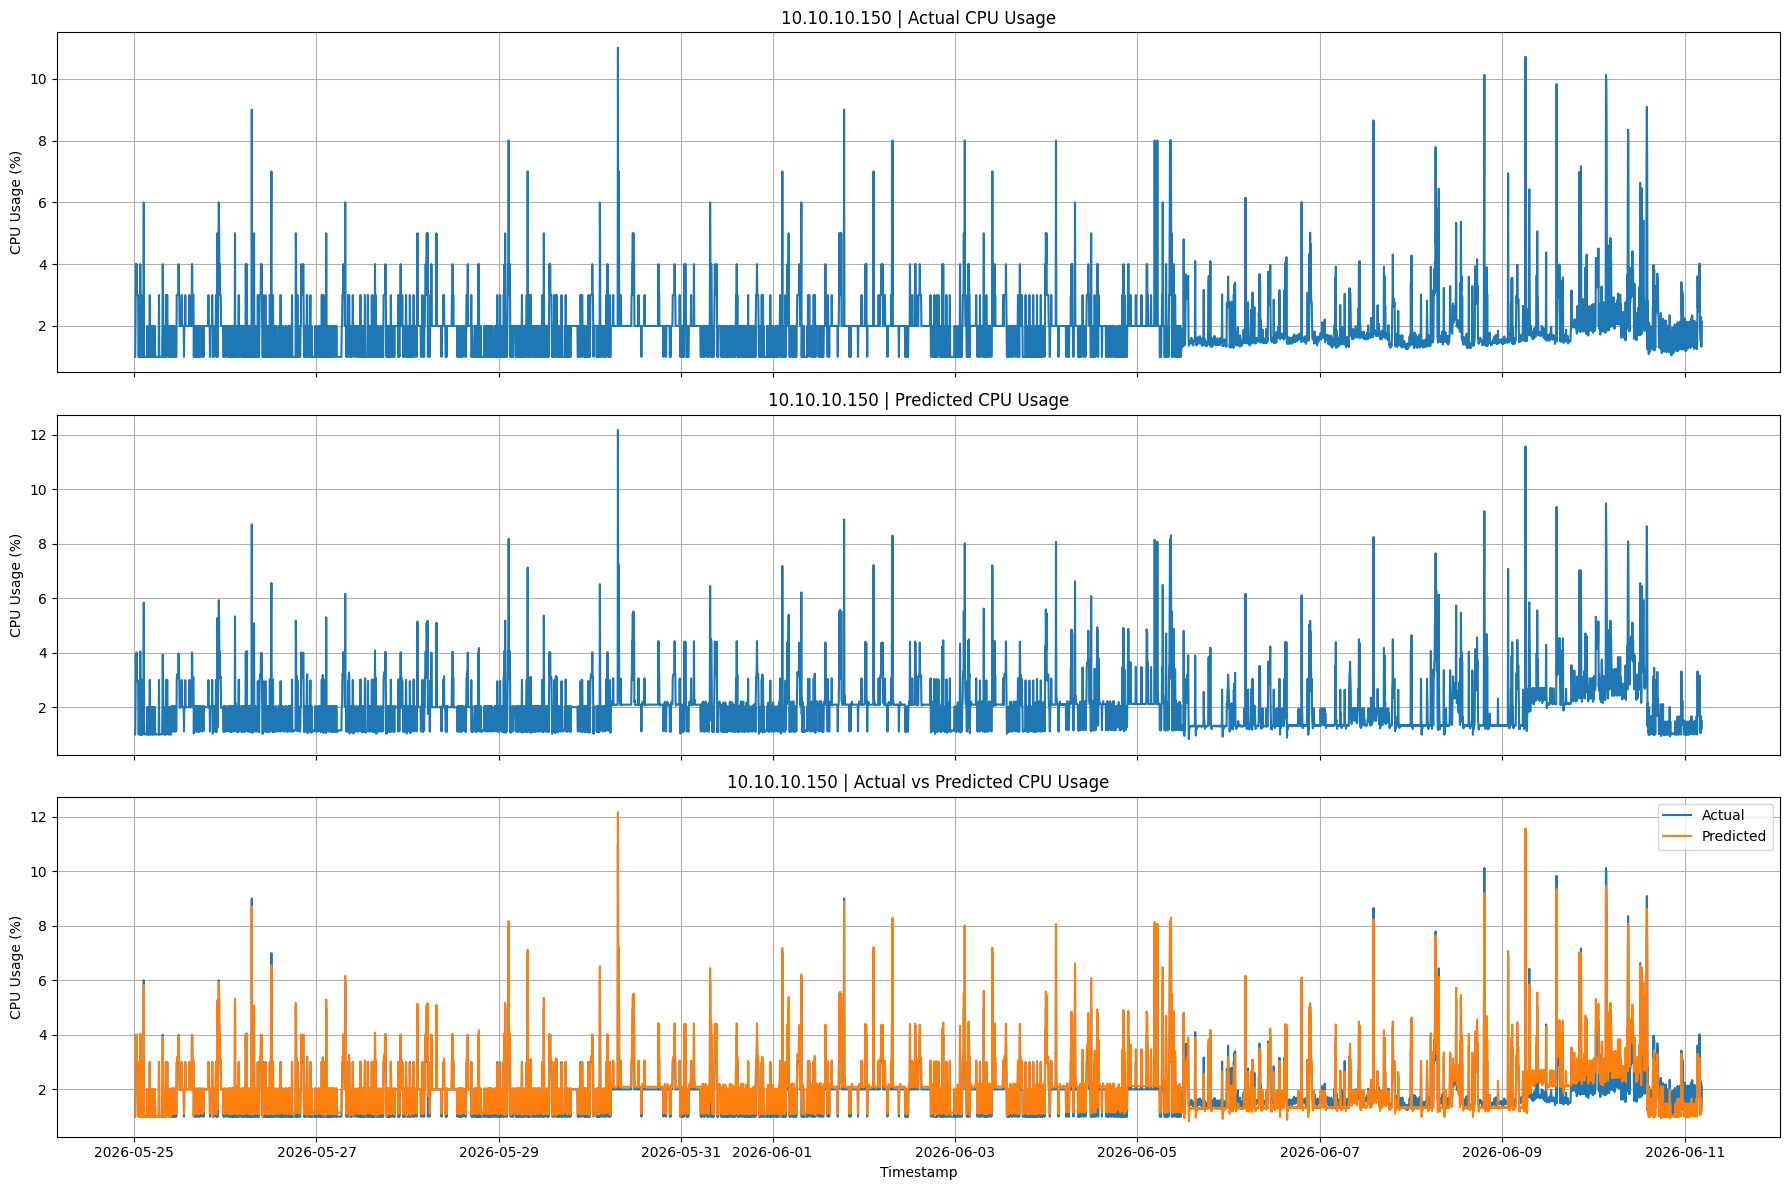

In [12]:
# get the hostname
SERVER_NAME = df['hostName'].iloc[0]
print(SERVER_NAME)

# Plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(
    3,
    1,
    figsize=(18, 12),
    sharex=True
)
# -----------------------------
# Actual CPU
# -----------------------------
axes[0].plot(
    results['Timestamp'],
    results['Actual']
)
axes[0].set_title(
    f'{SERVER_NAME} | Actual CPU Usage'
)
axes[0].set_ylabel(
    'CPU Usage (%)'
)
axes[0].grid(True)
# -----------------------------
# Predicted CPU
# -----------------------------
axes[1].plot(
    results['Timestamp'],
    results['Predicted']
)
axes[1].set_title(
    f'{SERVER_NAME} | Predicted CPU Usage'
)
axes[1].set_ylabel(
    'CPU Usage (%)'
)
axes[1].grid(True)
# -----------------------------
# Actual vs Predicted
# -----------------------------
axes[2].plot(
    results['Timestamp'],
    results['Actual'],
    label='Actual'
)
axes[2].plot(
    results['Timestamp'],
    results['Predicted'],
    label='Predicted'
)
axes[2].set_title(
    f'{SERVER_NAME} | Actual vs Predicted CPU Usage'
)
axes[2].set_ylabel(
    'CPU Usage (%)'
)
axes[2].set_xlabel(
    'Timestamp'
)
axes[2].legend()
axes[2].grid(True)
plt.tight_layout()

plt.show()

PREDICTING THE NEXT 1 HOUR FROM PREVIOUS 12 HOURS

In [13]:
# Create 12-hour history (144 timestamps)
HISTORY_WINDOW = 144
for lag in range(1, HISTORY_WINDOW + 1):

    df[f'cpu_lag_{lag}'] = (
        df['cpu_usage_pct']
        .shift(lag)
    )

# Create 1-hour future targets
# Predict next 1 hour
FORECAST_HORIZON = 12
for step in range(1, FORECAST_HORIZON + 1):

    df[f'target_t+{step}'] = (
        df['cpu_usage_pct']
        .shift(-step)
    )

C:\Users\Avilasha\AppData\Local\Temp\ipykernel_22576\985982438.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'cpu_lag_{lag}'] = (
C:\Users\Avilasha\AppData\Local\Temp\ipykernel_22576\985982438.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'cpu_lag_{lag}'] = (
C:\Users\Avilasha\AppData\Local\Temp\ipykernel_22576\985982438.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

In [14]:
# Remove missing rows
df_multi = df.dropna().copy()
print(df_multi.shape)

(24583, 185)


In [15]:
# Build feature list
# CPU Lag features
CPU_LAGS = [
    f'cpu_lag_{i}'
    for i in range(1, HISTORY_WINDOW + 1)
]
# Final features
FEATURES = (
    CPU_LAGS +
    [
        'memory_usage_pct',
        'power_kw',
        'cpu_temp_c',
        'inlet_temp_c',
        'cpu_change',
        'cpu_roll_mean_3',
        'cpu_volatility',
        'resource_stress_index',
        'hour_of_day',
        'day_of_week',
        'is_weekend'
    ]
)
# Create target columns
TARGETS = [
    f'target_t+{i}'
    for i in range(1, FORECAST_HORIZON + 1)
]
print(TARGETS)

['target_t+1', 'target_t+2', 'target_t+3', 'target_t+4', 'target_t+5', 'target_t+6', 'target_t+7', 'target_t+8', 'target_t+9', 'target_t+10', 'target_t+11', 'target_t+12']


In [16]:
# Train-test split
split_index = int(
    len(df_multi) * 0.8
)
train_df = df_multi.iloc[:split_index]
test_df = df_multi.iloc[split_index:]
print(train_df.shape)
print(test_df.shape)

(19666, 185)
(4917, 185)


In [17]:
# Create X and Y datasets
X_train = train_df[FEATURES]
Y_train = train_df[TARGETS]
X_test = test_df[FEATURES]
Y_test = test_df[TARGETS]
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test :", X_test.shape)
print("Y_test :", Y_test.shape)

X_train: (19666, 155)
Y_train: (19666, 12)
X_test : (4917, 155)
Y_test : (4917, 12)


In [18]:
# Sanity check
print(X_train.isna().sum().sum())
print(Y_train.isna().sum().sum())

0
0


In [19]:
# Train Multi-Output XGBoost
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
multi_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=1000,    # 300
        max_depth=10,    #8
        learning_rate=0.02, #0.05
        subsample=0.9,  #0.8
        colsample_bytree=0.9,   #0.8
        random_state=42,    #42
        tree_method='hist'
    )
)
multi_model.fit(
    X_train,
    Y_train
)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"XGBRegressor(...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None


In [20]:
# Predict
predictions = multi_model.predict(
    X_test
)
print(predictions.shape)

(4917, 12)


In [21]:
actual_1hr = Y_test.iloc[:, -1]
predicted_1hr = predictions[:, -1]

In [22]:
results_1hr = pd.DataFrame({

    'host_id':
        test_df['host_id'].values,

    'hostName':
        test_df['hostName'].values,

    'Timestamp':
        test_df['ts'].values,

    'cpu_usage_pct':
        actual_1hr.values,

    'Actual_1hr':
        actual_1hr.values,

    'Predicted_1hr':
        predicted_1hr,

    'memory_usage_pct':
        test_df['memory_usage_pct'].values,

    'power_kw':
        test_df['power_kw'].values,

    'cpu_temp_c':
        test_df['cpu_temp_c'].values,

    'inlet_temp_c':
        test_df['inlet_temp_c'].values,

    'resource_stress_index':
        test_df['resource_stress_index'].values

})

In [23]:
# Overall metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
overall_mae = mean_absolute_error(
    Y_test.values.flatten(),
    predictions.flatten()

)
overall_rmse = np.sqrt(
    mean_squared_error(
        Y_test.values.flatten(),
        predictions.flatten()
    )
)
overall_r2 = r2_score(
    Y_test.values.flatten(),
    predictions.flatten()
)
print("Overall MAE :", overall_mae)
print("Overall RMSE:", overall_rmse)
print("Overall R²  :", overall_r2)

Overall MAE : 0.6237502791839781
Overall RMSE: 0.9790992373215147
Overall R²  : -0.06196358817234149


In [24]:
# Horizon-wise metrics
for step in range(FORECAST_HORIZON):

    mae = mean_absolute_error(
        Y_test.iloc[:, step],
        predictions[:, step]
    )
    print(
        f"Step {step+1:02d}: MAE = {mae:.4f}"
    )

Step 01: MAE = 0.5823
Step 02: MAE = 0.5520
Step 03: MAE = 0.6583
Step 04: MAE = 0.6268
Step 05: MAE = 0.6428
Step 06: MAE = 0.6339
Step 07: MAE = 0.6147
Step 08: MAE = 0.6211
Step 09: MAE = 0.6206
Step 10: MAE = 0.6392
Step 11: MAE = 0.6457
Step 12: MAE = 0.6475


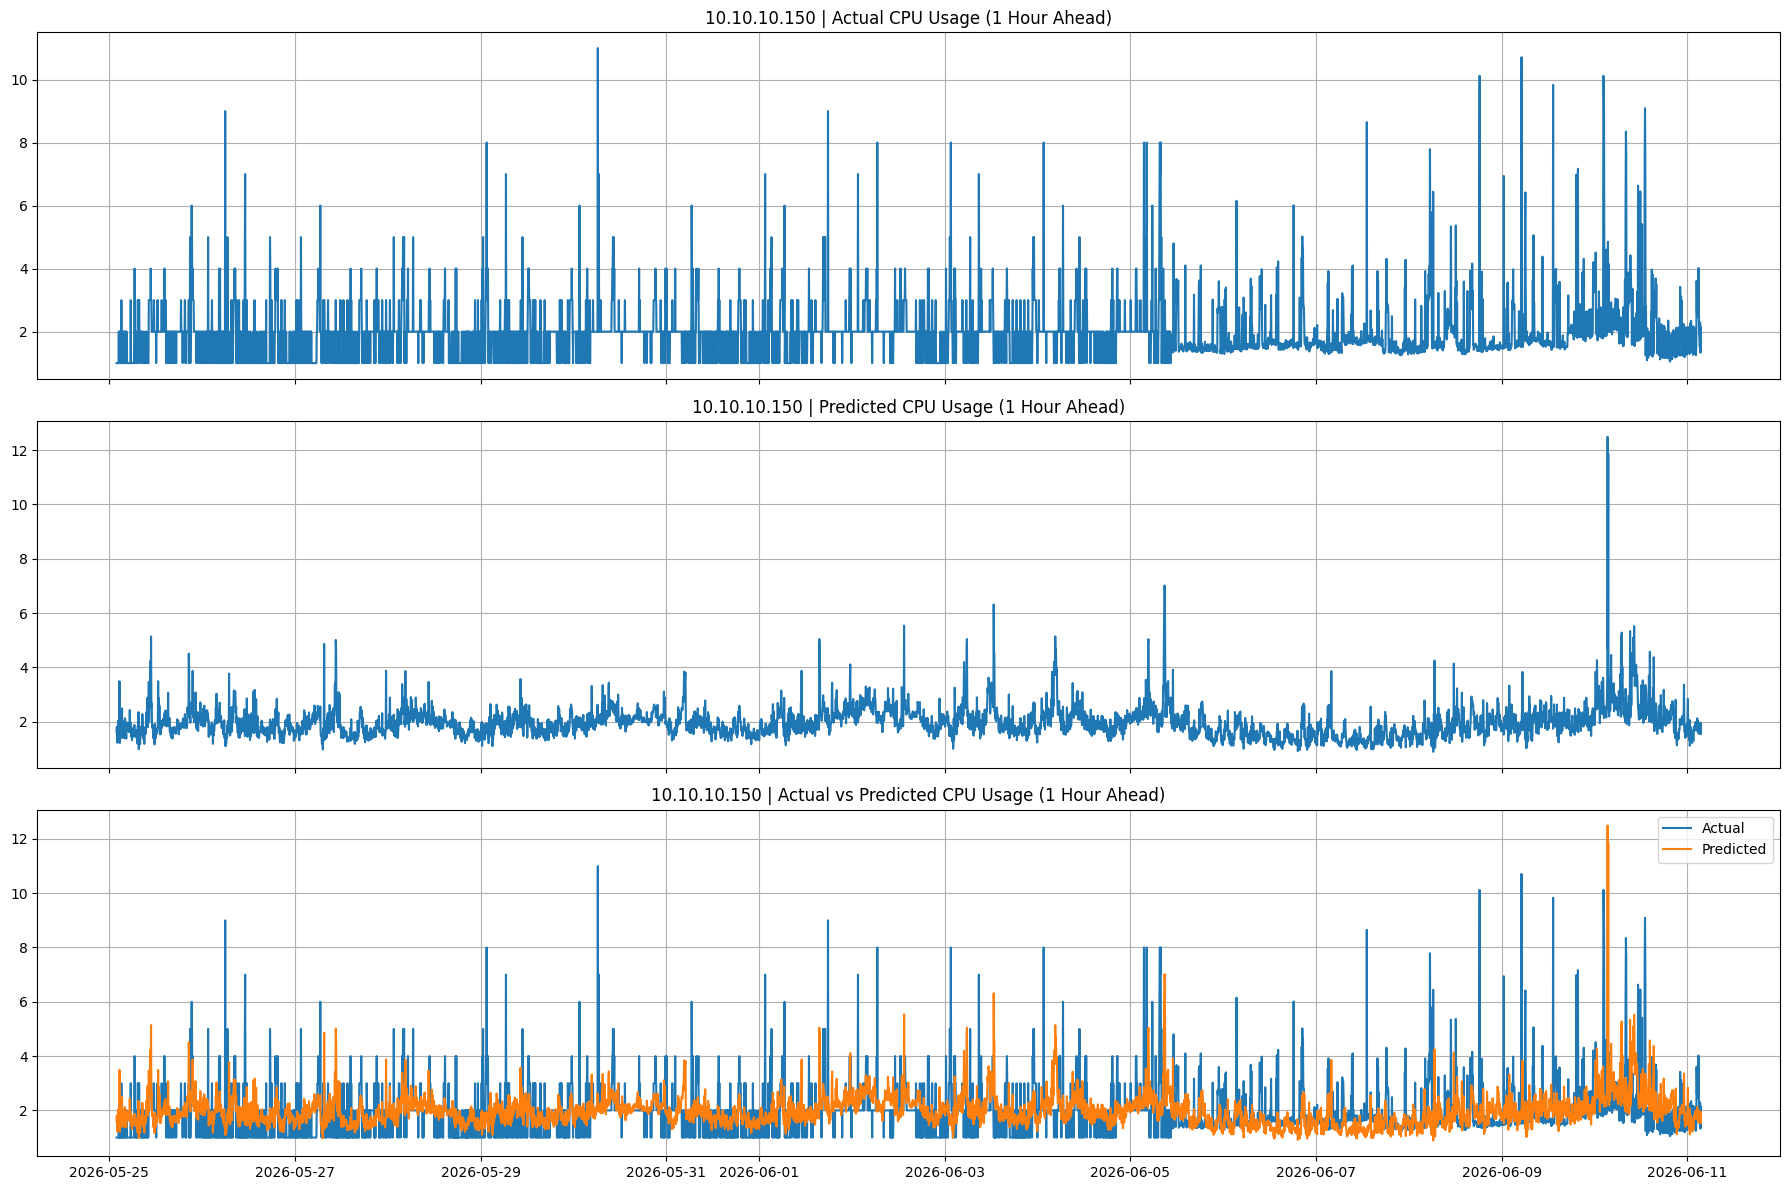

In [25]:
# Forecast visualization
fig, axes = plt.subplots(
    3,
    1,
    figsize=(18,12),
    sharex=True
)
# Actual
axes[0].plot(
    results_1hr['Timestamp'],
    results_1hr['Actual_1hr']
)
axes[0].set_title(
    f'{SERVER_NAME} | Actual CPU Usage (1 Hour Ahead)'
)
axes[0].grid(True)
# Predicted
axes[1].plot(
    results_1hr['Timestamp'],
    results_1hr['Predicted_1hr']
)
axes[1].set_title(
    f'{SERVER_NAME} | Predicted CPU Usage (1 Hour Ahead)'
)
axes[1].grid(True)
# Combined
axes[2].plot(
    results_1hr['Timestamp'],
    results_1hr['Actual_1hr'],
    label='Actual'
)
axes[2].plot(
    results_1hr['Timestamp'],
    results_1hr['Predicted_1hr'],
    label='Predicted'
)
axes[2].set_title(
    f'{SERVER_NAME} | Actual vs Predicted CPU Usage (1 Hour Ahead)'
)
axes[2].legend()
axes[2].grid(True)
plt.tight_layout()
plt.show()

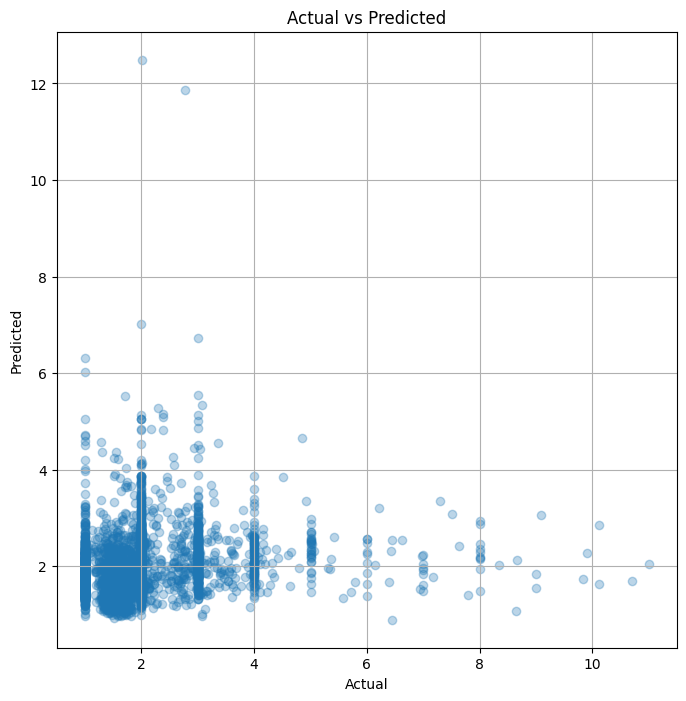

In [26]:
plt.figure(figsize=(8,8))
plt.scatter(
    actual_1hr,
    predicted_1hr,
    alpha=0.3
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

In [27]:
# results_1hr.to_csv(
#     "forecast_results_2.csv",
#     index=False
# )